# 04 · Real-world plants via system identification

The ML predictor is trained on synthetic plants, but ControlBench also works on **real physical systems**. The catch: a real system does not hand you a transfer function — it hands you *measured signals*. So we add one step at the front:

> real measured `(u, y)`  →  **identify** a transfer function `G(s)`  →  ControlBench recommends a controller.

We use two public benchmark datasets:

* **Hair dryer** — DaISy (KU Leuven): heater voltage in, air temperature out. Nearly linear.
* **Cascaded tanks** — 4TU nonlinear benchmark: pump voltage in, water level out. Mildly nonlinear.

Identification uses `controlbench.sysid`: a least-squares **ARX** fit, whose poles are mapped to continuous time with a DC-gain match. It is approximate — we always report and plot the fit rather than trusting it blindly.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

> **Data:** run `python scripts/download_data.py` once to fetch both datasets into `data/real/` (they are third-party research data, not stored in the repo).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import control as ct
from controlbench.sysid import identify_plant, fit_percent
from controlbench.compare import compare_controllers
from controlbench.ml import load_models, predict
models = load_models('../models')

## A. Hair dryer (DaISy)
A laboratory setup: air is fanned through a tube and heated at the inlet; the input is the heater voltage, the output is the air temperature. Sampling interval `Ts = 0.08 s`.

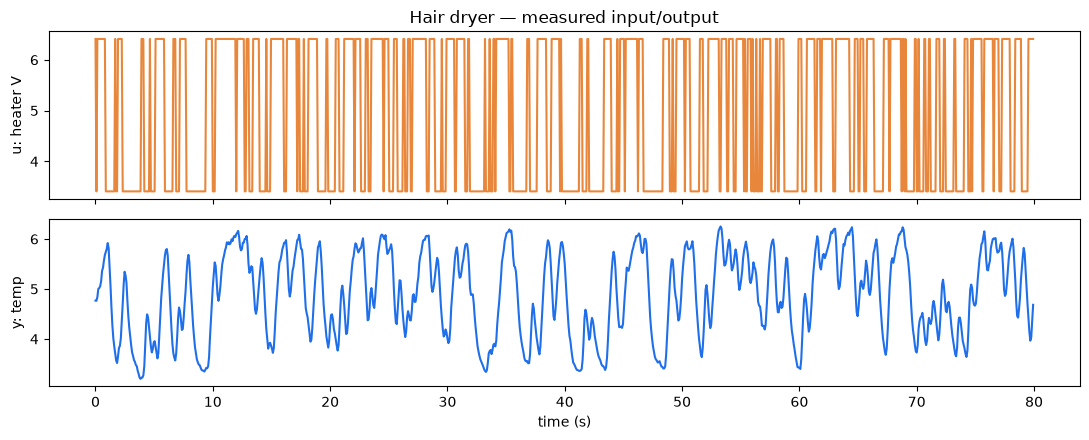

In [3]:
d = np.loadtxt('../data/real/dryer.dat')
u, y = d[:, 0], d[:, 1]
Ts = 0.08
fig, ax = plt.subplots(2, 1, figsize=(11, 4.5), sharex=True)
t = np.arange(len(u)) * Ts
ax[0].plot(t, u, color='#e8873b'); ax[0].set_ylabel('u: heater V')
ax[1].plot(t, y, color='#1f6feb'); ax[1].set_ylabel('y: temp'); ax[1].set_xlabel('time (s)')
ax[0].set_title('Hair dryer — measured input/output'); plt.tight_layout(); plt.show()

### Identify G(s) and check the fit

identified G(s): PlantModel(num=[122.56000843259442], den=[1.0, 13.3066202676705, 88.00053189434209, 156.15627894593212], order=3)
poles: [-5.357+5.615j -5.357-5.615j -2.593+0.j   ]
continuous-model fit: 68.3%


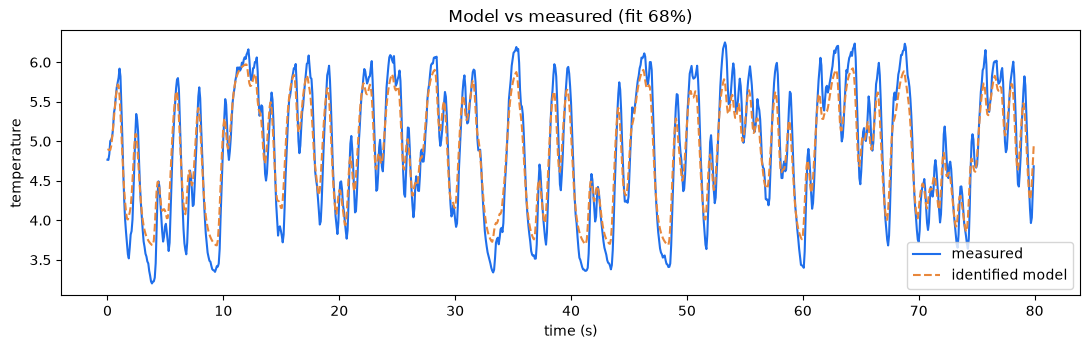

In [4]:
res = identify_plant(u, y, Ts, na=3, nb=2)
print('identified G(s):', res.plant)
print('poles:', np.round(res.plant.poles, 3))
print(f'continuous-model fit: {res.fit_percent:.1f}%')

plt.figure(figsize=(11, 3.6))
plt.plot(t, y, color='#1f6feb', label='measured')
plt.plot(t, res.y_sim + res.y_mean, '--', color='#e8873b', label='identified model')
plt.legend(); plt.xlabel('time (s)'); plt.ylabel('temperature')
plt.title(f'Model vs measured (fit {res.fit_percent:.0f}%)'); plt.tight_layout(); plt.show()

A pole-only 3rd-order model captures the dominant dynamics (~68% fit). The discrete ARX fits a little better (~74%); the gap is the price of the simple pole-only continuous conversion — an honest limitation, not a hidden one.

### Recommend a controller for the real dryer

In [5]:
ranked, controllers, _ = compare_controllers(res.plant)
print(f"{'ctrl':6}{'score':>7}{'settle(s)':>11}{'over%':>8}")
for r in ranked:
    m = r.metrics
    print(f'{r.name:6}{r.score:>7.3f}{m.settling_time:>11.2f}{m.overshoot:>8.1f}')
print('\nfull-simulation pick :', ranked[0].name)
print('ML instant prediction:', predict(res.plant, models))

ctrl    score  settle(s)   over%
Lead    0.614       1.98    47.8
PI      0.567       3.77    43.6
Lag     0.549      24.35     0.0
PID     0.547       2.81    50.7
P       0.540       3.01    47.6

full-simulation pick : Lead


ML instant prediction: {'recommended_controller': 'Lead', 'predicted_settling_time': 3.0592286206418904, 'predicted_overshoot': 19.33941944288103}


## B. Cascaded tanks (4TU benchmark)
Water is pumped into an upper tank that drains into a lower tank; the input is the pump voltage, the output is the lower-tank level. It is **mildly nonlinear** (overflow, square-root outflow), so a linear fit is rougher — and the dataset ships a separate validation set, so we fit on one and test on the other. Sampling interval `Ts = 4 s`.

In [6]:
df = pd.read_csv('../data/real/cascaded_tanks/dataBenchmark.csv')
uE, yE, uV, yV = df['uEst'].values, df['yEst'].values, df['uVal'].values, df['yVal'].values
Ts = float(df['Ts'].dropna().iloc[0])
res = identify_plant(uE, yE, Ts, na=3, nb=2)
print('identified G(s):', res.plant)
print('poles:', np.round(res.plant.poles, 4))
print(f'estimation fit: {res.fit_percent:.1f}%')

identified G(s): PlantModel(num=[0.00020522912121896412], den=[1.0, 0.27665830998154645, 0.010784220050675891, 4.816479045442849e-05], order=3)
poles: [-0.2308+0.j -0.0407+0.j -0.0051+0.j]
estimation fit: 71.9%


### Validate on the held-out validation set

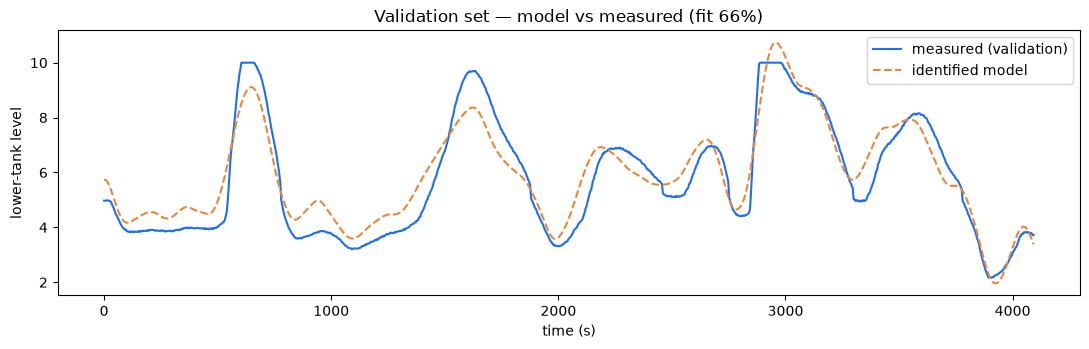

validation fit: 66.1%


In [7]:
tV = np.arange(len(uV)) * Ts
_, yV_sim = ct.forced_response(res.plant.tf, T=tV, U=uV - uV.mean())
val_fit = fit_percent(yV - yV.mean(), yV_sim)
plt.figure(figsize=(11, 3.6))
plt.plot(tV, yV, color='#1f6feb', label='measured (validation)')
plt.plot(tV, yV_sim + yV.mean(), '--', color='#e8873b', label='identified model')
plt.legend(); plt.xlabel('time (s)'); plt.ylabel('lower-tank level')
plt.title(f'Validation set — model vs measured (fit {val_fit:.0f}%)')
plt.tight_layout(); plt.show()
print(f'validation fit: {val_fit:.1f}%')

### Recommend a controller for the real tanks

In [8]:
ranked, _, _ = compare_controllers(res.plant)
print(f"{'ctrl':6}{'score':>7}{'settle(s)':>11}{'over%':>8}")
for r in ranked:
    m = r.metrics
    print(f'{r.name:6}{r.score:>7.3f}{m.settling_time:>11.1f}{m.overshoot:>8.1f}')
print('\nrecommended:', ranked[0].name)

ctrl    score  settle(s)   over%
PID     0.772      213.4    59.4
Lead    0.643      903.1    31.4
P       0.641      386.0    64.6
Lag     0.532     4821.6     0.0
PI      0.340     3941.3    98.0

recommended: PID


The tanks are slow (settling in hundreds of seconds) and only mildly linear, so the fit is lower than the dryer's — exactly what you would expect. Still, the same pipeline takes raw sensor measurements from a real rig and returns a concrete controller recommendation.

**Takeaway:** ControlBench is not limited to textbook transfer functions. Point it at real measured data, identify a model, and it recommends a controller for the physical system.